<a href="https://colab.research.google.com/github/VIRAT9369/IPL-Cricket-Data-Analysis/blob/main/IPL_Data_Analysis_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Ipl Data Analysis Project

Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use('ggplot')

Load Dataset

In [9]:
from google.colab import files
uploaded = files.upload()

# Load datasets
matches = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')

print("Matches Shape:", matches.shape)
print("Deliveries Shape:", deliveries.shape)

matches.head()

Saving deliveries.csv to deliveries.csv
Saving matches.csv to matches.csv
Matches Shape: (1095, 20)
Deliveries Shape: (260920, 17)


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


Dataset Information

In [10]:
print(matches.info())

print("\nMissing Values in Matches")
print(matches.isnull().sum())

print("\nDuplicate Rows")
print(matches.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

Business Question 1: Which Team Won Most Matches?

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Sunrisers Hyderabad             88
Kings XI Punjab                 88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29
Gujarat Titans                  28
Punjab Kings                    24
Lucknow Super Giants            24
Gujarat Lions                   13
Pune Warriors                   12
Rising Pune Supergiant          10
Royal Challengers Bengaluru      7
Kochi Tuskers Kerala             6
Rising Pune Supergiants          5
Name: count, dtype: int64


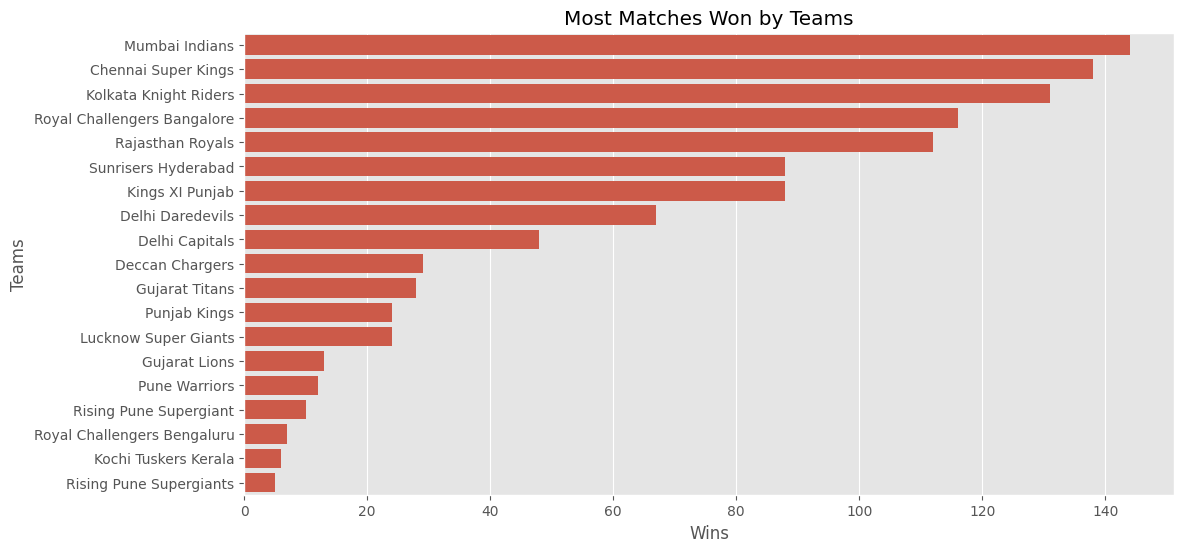

In [11]:
team_wins = matches['winner'].value_counts()

print(team_wins)

plt.figure(figsize=(12,6))
sns.barplot(x=team_wins.values, y=team_wins.index)

plt.title("Most Matches Won by Teams")
plt.xlabel("Wins")
plt.ylabel("Teams")
plt.show()

Business Question 2: Best Venue

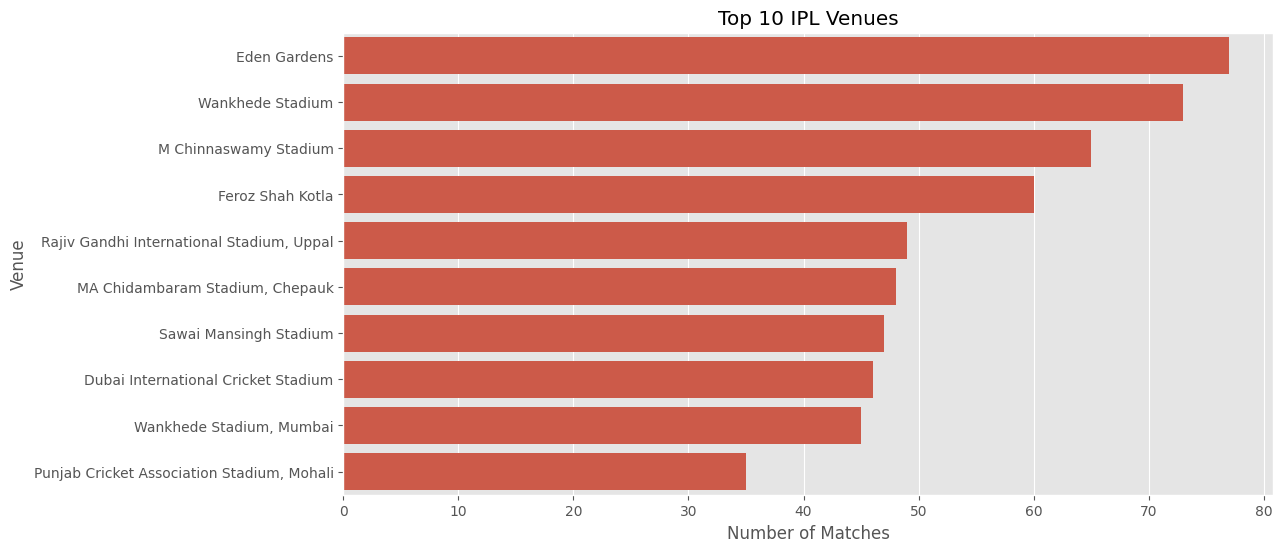

venue
Eden Gardens                                  77
Wankhede Stadium                              73
M Chinnaswamy Stadium                         65
Feroz Shah Kotla                              60
Rajiv Gandhi International Stadium, Uppal     49
MA Chidambaram Stadium, Chepauk               48
Sawai Mansingh Stadium                        47
Dubai International Cricket Stadium           46
Wankhede Stadium, Mumbai                      45
Punjab Cricket Association Stadium, Mohali    35
Name: count, dtype: int64


In [12]:
venue_matches = matches['venue'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=venue_matches.values, y=venue_matches.index)

plt.title("Top 10 IPL Venues")
plt.xlabel("Number of Matches")
plt.ylabel("Venue")
plt.show()

print(venue_matches)

Business Question 3: Toss Impact on Winning


In [13]:
toss_impact = matches[matches['toss_winner'] == matches['winner']]

impact_percent = (len(toss_impact) / len(matches)) * 100

print("Toss Winning Impact:", round(impact_percent,2), "%")

Toss Winning Impact: 50.59 %


Business Question 4: Highest Run Chase

In [14]:
if 'target_runs' in matches.columns:
    highest_chase = matches.sort_values(
        by='target_runs',
        ascending=False
    )

    print(highest_chase[
        ['winner','target_runs','venue']
    ].head())
else:
    print("target_runs column not available")

                           winner  target_runs  \
1053          Sunrisers Hyderabad        288.0   
1031          Sunrisers Hyderabad        278.0   
1039        Kolkata Knight Riders        273.0   
1058          Sunrisers Hyderabad        267.0   
352   Royal Challengers Bangalore        264.0   

                                                  venue  
1053                   M Chinnaswamy Stadium, Bengaluru  
1031  Rajiv Gandhi International Stadium, Uppal, Hyd...  
1039  Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket St...  
1058                        Arun Jaitley Stadium, Delhi  
352                               M Chinnaswamy Stadium  


Business Question 5: Team Performance Trends

In [15]:
season_wins = matches.groupby(
    ['season','winner']
).size().reset_index(name='wins')

season_wins.head()

,season,winner,wins
0,2007/08,Chennai Super Kings,9
1,2007/08,Deccan Chargers,2
2,2007/08,Delhi Daredevils,7
3,2007/08,Kings XI Punjab,10
4,2007/08,Kolkata Knight Riders,6


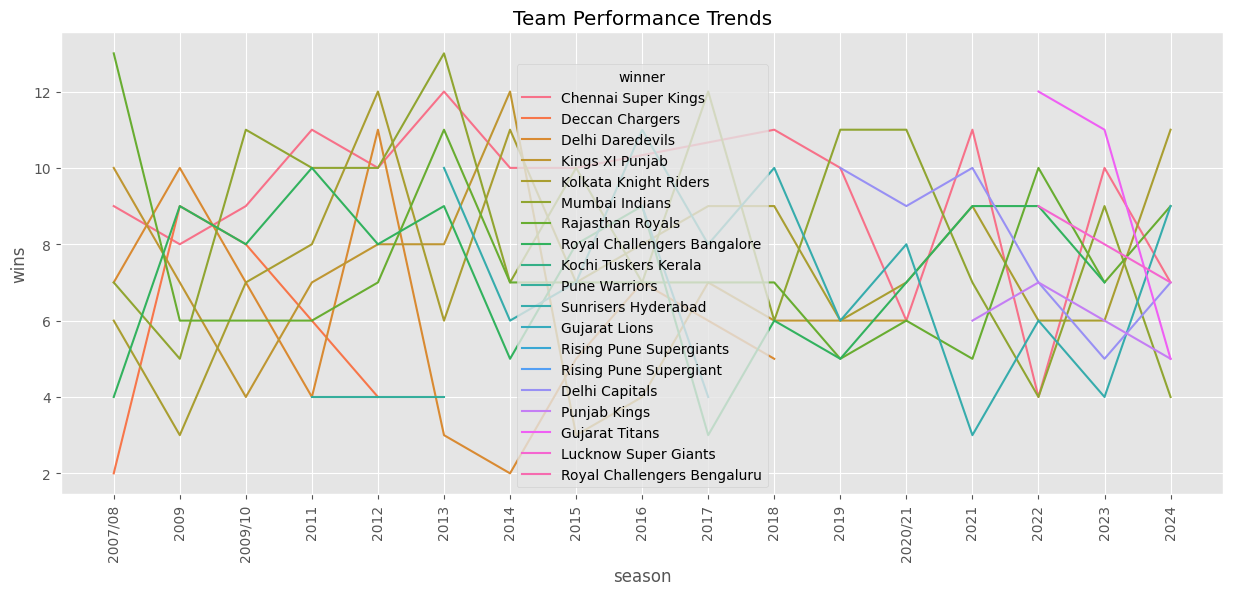

In [16]:
plt.figure(figsize=(15,6))

sns.lineplot(
    data=season_wins,
    x='season',
    y='wins',
    hue='winner'
)

plt.title("Team Performance Trends")
plt.xticks(rotation=90)
plt.show()

Team Win Percentage


In [17]:
matches_played = pd.concat([matches['team1'], matches['team2']]).value_counts()
wins = matches['winner'].value_counts()

win_percent = (wins / matches_played * 100).sort_values(ascending=False)

print(win_percent.head(10))

Rising Pune Supergiant         62.500000
Gujarat Titans                 62.222222
Chennai Super Kings            57.983193
Mumbai Indians                 55.172414
Lucknow Super Giants           54.545455
Delhi Capitals                 52.747253
Kolkata Knight Riders          52.191235
Rajasthan Royals               50.678733
Sunrisers Hyderabad            48.351648
Royal Challengers Bangalore    48.333333
Name: count, dtype: float64


Heatmap

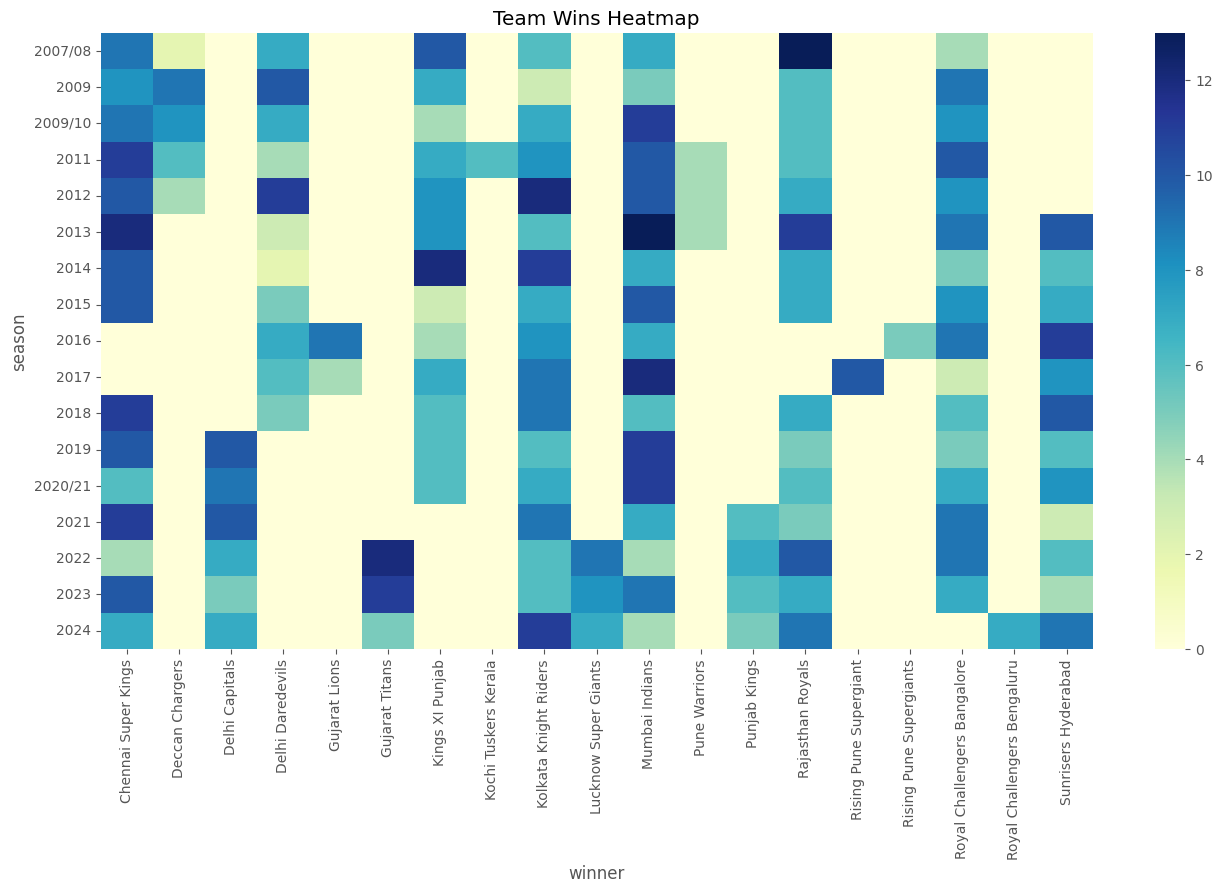

In [18]:
heatmap_data = matches.pivot_table(
    index='season',
    columns='winner',
    aggfunc='size',
    fill_value=0
)

plt.figure(figsize=(16,8))

sns.heatmap(
    heatmap_data,
    cmap='YlGnBu'
)

plt.title("Team Wins Heatmap")
plt.show()

Scatter Plot: Team Scores

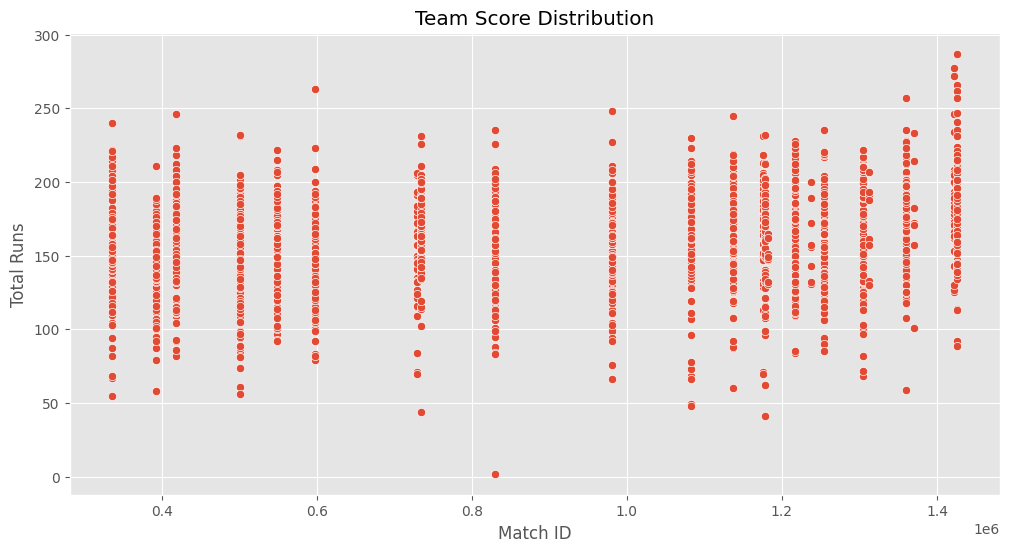

In [19]:
team_scores = deliveries.groupby(
    ['match_id','batting_team']
)['total_runs'].sum().reset_index()

plt.figure(figsize=(12,6))

sns.scatterplot(
    data=team_scores,
    x='match_id',
    y='total_runs'
)

plt.title("Team Score Distribution")
plt.xlabel("Match ID")
plt.ylabel("Total Runs")
plt.show()

Interactive Plotly Dashboard

In [20]:
fig = px.bar(
    x=team_wins.index,
    y=team_wins.values,
    title="IPL Team Wins Dashboard",
    labels={
        'x':'Team',
        'y':'Wins'
    }
)

fig.show()

Conclusion

In [ ]:
print("IPL DATA ANALYSIS PROJECT CONCLUSION")
print("1. Mumbai Indians and Chennai Super Kings are among the most successful teams.")
print("2. Certain venues host significantly more IPL matches.")
print("3. Toss-winning teams won around 50.59% matches.")
print("4. Highest target in dataset is 288 runs.")
print("5. Team performance changes across seasons.")

IPL DATA ANALYSIS PROJECT CONCLUSION
1. Mumbai Indians and Chennai Super Kings are among the most successful teams.
2. Certain venues host significantly more IPL matches.
3. Toss-winning teams won around 50.59% matches.
4. Highest target in dataset is 288 runs.
5. Team performance changes across seasons.
